# Homework 4: The Bootstrap

BEE 4850/5850, Fall 2025

**Name**: Madeline Allen

**ID**:

> **Due Date**
>
> Friday, 3/28/25, 9:00pm



## Note to Gaby:
Just FYI - I tried to summarize key points for each problem at the end of each problem! :)

## Overview

### Instructions

The goal of this homework assignment is to practice simulation-based
uncertainty quantification, focusing on the bootstrap.

-   Problem 1 asks you to use the non-parametric bootstrap to estimate
    uncertainty in a Poisson regression model.
-   Problem 2 asks you to use the bootstrap (through resampling
    residuals) to estimate uncertainty in a semi-empirical sea-level
    rise model.
-   Problem 3 (only required for students in BEE 5850) asks you to use a
    moving block bootstrap to estimate the sampling distribution of the
    median of extreme water level data.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [221]:
import random  # random number generation and seed-setting
import pandas as pd  # tabular data structure
import csv  # reads/writes .csv files (though pandas is usually used for this)
import numpy as np  # numerical computing
import scipy.stats as stats  # interface to work with probability distributions
import matplotlib.pyplot as plt  # plotting library
import seaborn as sns  # additional statistical plotting tools
import statistics  # statistical quantities like mean, median, etc.
from scipy.optimize import minimize  # optimization tools
from scipy.stats import norm
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import poisson
random.seed(44)


## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 10 points;
-   Problem 3 is worth 5 points;

### Problem 1

Revisit the salamander model from [Homework
2](https://viveks.me/simulation-data-analysis/hw/hw02.html), using
percent groundcover as a predictor in the Poisson regression. Use the
non-parametric bootstrap to estimate bias and confidence intervals for
the model parameters.

**In this problem**:

-   Load the data from `data/salamanders.csv`.
-   Fit a Poisson regression model for salamander counts using the
    percentage of ground cover.
-   Use 1,000 non-parametric bootstrap samples to obtain estimates of
    bias and the 90% confidence interval for the intercept and
    coefficient in the Poisson regression.

In [222]:
sal = pd.read_csv("data/salamanders.csv", delimiter=";") 
# print(sal.head(5))

In [223]:
# Standardize predictors
sal['PCTCOVER_scale'] = (sal['PCTCOVER'] - sal['PCTCOVER'].mean())/sal['PCTCOVER'].std()

The structure of my poisson model is:

$y_i \sim Poisson(\lambda_i)$

$f(\lambda_i) = beta_0 + beta_1 * PCTCOVER$

$\lambda_i = f^{-1} (beta_0 + beta_1 * PCTCOVER)$

And for this Poisson model, I think it makes sense to use the log link function (converting all real numbers that come out of the $beta_0 + beta_1 * PCTCOVER$ into only postive rate constant values).

So my model would be:

$y_i \sim Poisson(\lambda_i)$ where $\lambda_i = e\^{}(beta_0 + beta_1 * PCTCOVER)$

Note that in the above, I've kept it labeled as "PCTCOVER" but we're actually using a standardized version of that. 

In [224]:
# Poisson model
model = smf.glm(formula='SALAMAN ~ PCTCOVER_scale', data=sal, 
                family=sm.families.Poisson()).fit()
# print(model.summary())

# estimated parameters
β0_hat = model.params['Intercept']
β1_hat = model.params['PCTCOVER_scale']


In [225]:
# # Plot:
# plt.figure(figsize=(8,5)) 
# plt.scatter(sal['PCTCOVER_scale'], sal['SALAMAN'], label = 'Observed', color = 'darkmagenta', alpha = 0.8)
# # plot 90% prediction intervals using the stored sal['lower_bound'] and sal['upper_bound']
# sorted_df = sal.sort_values('PCTCOVER_scale')
# plt.plot(sorted_df['PCTCOVER_scale'], sorted_df['est_lambda_hat'])
# plt.fill_between(sorted_df['PCTCOVER_scale'], sorted_df['lower_bound'], sorted_df['upper_bound'], alpha= 0.3, label = '90% Prediction Interval')

# # Add labels
# plt.xlabel('Percent Forest Cover (Scaled)')
# plt.ylabel('Salamanders Count')
# plt.title('Observed and Estimated Salamander Count Based on Percent Forest Cover (Scaled)')
# plt.legend()
# plt.tight_layout()
# plt.show()

Now for the bootstrap:

In [226]:
# Use 1,000 non-parametric bootstrap samples to obtain estimates of bias and the 90% confidence interval 
# for the intercept and coefficient in the Poisson regression.
n_boot = 1000

# initialize to store params
bootstrap_params_poisson = []

for boot in range(n_boot):
    sal_boot = sal.sample(n=len(sal),replace=True)
    # Fit Poisson 
    model = smf.glm(formula='SALAMAN ~ PCTCOVER_scale', data=sal_boot, 
                    family=sm.families.Poisson()).fit()
    # print(model.summary())

    # Extract estimated parameters
    β0_boot = model.params['Intercept']
    β1_boot = model.params['PCTCOVER_scale']
    bootstrap_params_poisson.append({"β0_boot": β0_boot, "β1_boot": β1_boot})

# Convert to DataFrame
bootstrap_params_poisson_df = pd.DataFrame(bootstrap_params_poisson)


In [227]:
# Basic bootstrap confidence interval function:
#confidence intervals: 2 * param_sample_est - quantile_high <= actual param <= 2 * param_sample_est - quantile_low
def basic_boot_CI(param_sample_est, boot_sample, quantile_low = 0.05, quantile_high = 0.95): #default: 90% CI
    q_low, q_high = np.quantile(boot_sample, [quantile_low, quantile_high]) 
    boot_estimate = np.mean(boot_sample)

    #bias is bootstrap estimate minus the observed statistic:
    boot_bias = boot_estimate - param_sample_est
    estimate_true_param = param_sample_est-boot_bias
    boot_CI_low = 2 * param_sample_est - q_high
    boot_CI_high = 2 * param_sample_est - q_low
    return boot_estimate, boot_bias, estimate_true_param, boot_CI_low, boot_CI_high


**Estimates of bias and the 90% confidence interval for the intercept and coefficient in the Poisson regression:**

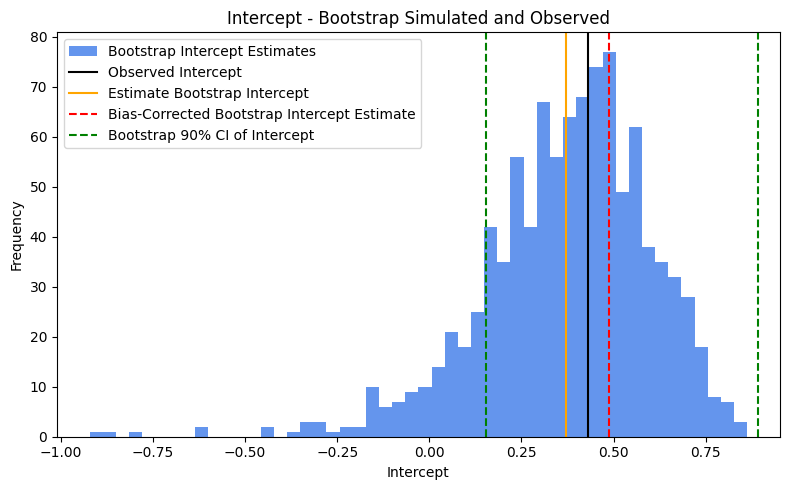

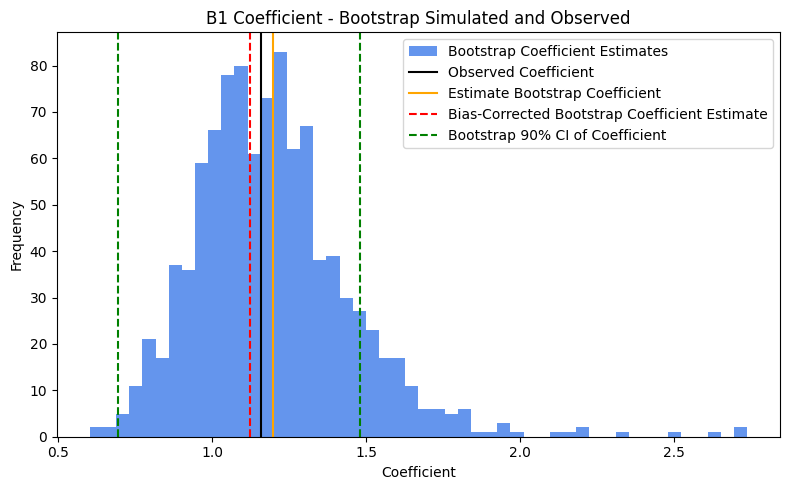

INTERCEPT:
The bootstrap estimate of the intercept is 0.37;
The bias in this estimator (bootstrap estimate 0.37 minus original "observed" intercept 0.43) is -0.06.
The bias-adjusted estimate of the intercept is: 0.49.
The 90% confidence interval in the intercept estimate is 0.15 to 0.89.
COEFFICIENT:
The bootstrap estimate of the B1 coefficient is 1.2;
The bias in this estimator (bootstrap estimate 1.2 minus original "observed" B1 coefficient 1.16) is 0.04.
The bias-adjusted estimate of the B1 coefficient is: 1.12.
The 90% confidence interval in the B1 coefficient estimate is 0.69 to 1.48.


In [259]:
boot_estimate_int, boot_bias_int, estimate_true_param_int, boot_CI_low_int, boot_CI_high_int = basic_boot_CI(param_sample_est=β0_hat, boot_sample=bootstrap_params_poisson_df['β0_boot'], quantile_low = 0.05, quantile_high = 0.95)
boot_estimate_B1, boot_bias_B1, estimate_true_param_B1, boot_CI_low_B1, boot_CI_high_B1 = basic_boot_CI(param_sample_est=β1_hat, boot_sample=bootstrap_params_poisson_df['β1_boot'], quantile_low = 0.05, quantile_high = 0.95)

# Plot intercept
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_params_poisson_df['β0_boot'], bins = 50, color = 'cornflowerblue', label = f'Bootstrap Intercept Estimates')
plt.axvline(x=β0_hat, color = 'black',label='Observed Intercept')
plt.axvline(x=boot_estimate_int, color = 'orange',label='Estimate Bootstrap Intercept')
plt.axvline(x=estimate_true_param_int, color = 'red', linestyle='--',label='Bias-Corrected Bootstrap Intercept Estimate')
plt.axvline(x=boot_CI_low_int, color = 'green', linestyle='--', label='Bootstrap 90% CI of Intercept')
plt.axvline(x=boot_CI_high_int, color = 'green', linestyle='--')
plt.xlabel("Intercept")
plt.ylabel("Frequency")
plt.legend()
plt.title(fr"Intercept - Bootstrap Simulated and Observed")
plt.tight_layout()
plt.show()

# Plot coefficient
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_params_poisson_df['β1_boot'], bins = 50, color = 'cornflowerblue', label = f'Bootstrap Coefficient Estimates')
plt.axvline(x=β1_hat, color = 'black',label='Observed Coefficient')
plt.axvline(x=boot_estimate_B1, color = 'orange',label='Estimate Bootstrap Coefficient')
plt.axvline(x=estimate_true_param_B1, color = 'red', linestyle='--',label='Bias-Corrected Bootstrap Coefficient Estimate')
plt.axvline(x=boot_CI_low_B1, color = 'green', linestyle='--', label='Bootstrap 90% CI of Coefficient')
plt.axvline(x=boot_CI_high_B1, color = 'green', linestyle='--')
plt.xlabel("Coefficient")
plt.ylabel("Frequency")
plt.legend()
plt.title(fr"B1 Coefficient - Bootstrap Simulated and Observed")
plt.tight_layout()
plt.show()



print('INTERCEPT:')
print(f'The bootstrap estimate of the intercept is {round(boot_estimate_int, 2)};')
print(f'The bias in this estimator (bootstrap estimate {round(boot_estimate_int, 2)} minus original "observed" intercept {round(β0_hat,2)}) is {round(boot_bias_int, 2)}.')
print(f'The bias-adjusted estimate of the intercept is: {round(estimate_true_param_int, 2)}.')
print(f'The 90% confidence interval in the intercept estimate is {round(boot_CI_low_int, 2)} to {round(boot_CI_high_int,2)}.')

print('COEFFICIENT:')
print(f'The bootstrap estimate of the B1 coefficient is {round(boot_estimate_B1, 2)};')
print(f'The bias in this estimator (bootstrap estimate {round(boot_estimate_B1, 2)} minus original "observed" B1 coefficient {round(β1_hat, 2)}) is {round(boot_bias_B1, 2)}.')
print(f'The bias-adjusted estimate of the B1 coefficient is: {round(estimate_true_param_B1, 2)}.')
print(f'The 90% confidence interval in the B1 coefficient estimate is {round(boot_CI_low_B1, 2)} to {round(boot_CI_high_B1,2)}.')


#### Commentary on Problem 1:

Above, a poisson regression model was fit to the salamander data, to represent salamander counts as a function of (standardized) percent forest cover. This original poisson model provided the original/"observed" estimates of the intercept and coefficient parameters. Then, 1,000 non-parametric bootstrap samples were produced (via randomly selecting rows from the original salamander dataset, with replacement, to create new samples); the same structural poisson regression model was fit to each bootstrap sample, and the resulting estimates of the intercept and coefficient were stored and visualized in the histogram plots above. Above this code block, the original estimate, bootstrap best estimate, bias, bias-corrected estimate, and 90% confidence intervals are shown for the intercept and coefficient. For the bias and 90% confidence intervals specifically: the intercept has a bias of -0.06, and a CI of 0.15 to 0.89, and the coefficient has a bias of 0.04 and a CI of 0.69 to 1.48.

### Problem 2

Revisit the sea-level rise model from [Homework
2](https://viveks.me/simulation-data-analysis/hw/hw02.html):

$$\begin{aligned}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{aligned}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$C (in mm).

We would like to quantify uncertainty in the model parameters using the
bootstrap.

**In this problem**:

-   Load the data from the `data/` folder and, following Grinsted et al
    (2010), normalize both datasets to the 1980-1999 mean (subtract that
    mean from the data).
    -   Global mean temperature data from the HadCRUT 5.0.2.0 dataset
        (<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
        can be found in
        `data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`.
        This data is averaged over the Northern and Southern Hemispheres
        and over the whole year.
    -   Global mean sea level anomalies (relative to the 1990 mean
        global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
        courtesy of CSIRO
        (<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The
        standard deviation of the estimate is also added for each year.
-   Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data and
    include an initial sea-level parameter $S_0$. This will be similar
    to the model from Homework 2. Fit this model to the data with AR(1)
    residuals.
-   Use your fitted model and the AR(1) residual process to generate
    1,000 parametric bootstrap samples. Refit the model to each. Plot
    histograms of the bootstrap samples for each parameter. What is the
    90% confidence interval for the sensitivity of sea level to global
    mean temperature?

**NOTE: Use of ChatGPT (OpenAI, 2025) in this problem:** I was really stuggling to figure out how to call the neg_log_likelihood_ar1 function within the bootstrap loop, while trying to optimize the parameters (that are supposed to be passed into it) - I asked Chatgpt how to do this and replaced the one line of code that uses minimize() with what chatgpt suggested (it showed me how to use lambda in order to pass the function that then becomes callable, within the minimization problem).

NOTE: similar to question 1, the beginning of my question largely uses code directly from my HW2 submission (just fyi :) ). As described in HW2 (in the suggested modification to the problem, given the time dependence of the residuals), the way I formulated this new model (adding the AR1 component)is: turning the discrepancy term frin HW2 into an AR(1) probability model. I.e., previously, the discrepancy term was normally distributed with mean zero and standard deviation sigma: $\delta_t \sim N(0, \sigma^2)$, I instead make the discrepancy term equal to $\delta_t = \delta_{t-1} + \omega_t$, where $\omega_t \sim N(0, \sigma^2)$. By changing this model formulation and again use MLE to obtain estimates of the parameters (now, with the addition of $\rho$).

In [242]:
#  Load data
temp = pd.read_csv("data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv") 
sea = pd.read_csv("data/CSIRO_Recons_gmsl_yr_2015.csv") 

# Round down the time on sea_lev_anom for simplicity, since 1880.5 is the mean sea level in 1880, as noted in ed discussion post
sea['Time'] = sea['Time'].astype(int)

# normalize both datasets to the 1980-1999 mean
temp_mean = temp[(temp['Time']>=1980) & (temp['Time']<=1999)]['Anomaly (deg C)'].mean()
print('Mean temp anomaly from 1980-1999:', temp_mean)
sea_mean = sea[(sea['Time']>=1980) & (sea['Time']<=1999)]['GMSL (mm)'].mean()
print('Mean sea level anomaly from 1980-1999:', sea_mean)

# subtract mean from data:
temp['temp_anom_normalized'] = temp['Anomaly (deg C)'] - temp_mean
sea['GMSL_anom_normalized'] = sea['GMSL (mm)'] - sea_mean
# print(temp.head(10))
# print(sea.head(10))

# # Figure out what years both datasets contain:
# print('temp min year: ', temp['Time'].min())
# print('temp max year: ', temp['Time'].max())
# print('sea min year: ', sea['Time'].min())
# print('sea max year: ', sea['Time'].max())

# we want 1880-2013; filter datasets:
temp_filt = temp[(temp['Time']>=1880)&(temp['Time']<=2013)].reset_index(drop=True)
sea_filt = sea[(sea['Time']>=1880)&(sea['Time']<=2013)].reset_index(drop=True)


Mean temp anomaly from 1980-1999: 0.24016621270000002
Mean sea level anomaly from 1980-1999: 0.375


### Initial Sea Level Model:

In [243]:
# Function to simulate global mean sea levels under a set of model parameters (discretized eqn):
def sea_level_model(a, b, tau, S0, global_temp = temp_filt['temp_anom_normalized']):    
    dt = 1 # 1 year 
    T = global_temp
    S = np.zeros(len(T))
    S[0] = S0    
    for i in range(len(T) - 1):
        S[i+1] = S[i] + ((a * T[i] + b - S[i])/tau)*dt
    return S

In [279]:
def neg_log_likelihood_ar1(params, sea_level_data=sea_filt['GMSL_anom_normalized'], global_temp=temp_filt['temp_anom_normalized']):
    a, b, tau, S0, rho, sigma = params

    # Simulate sea level using the model
    sea_level_sim = sea_level_model(a, b, tau, S0, global_temp=global_temp)

    # Compute residuals
    residuals =  sea_level_data - sea_level_sim

    # AR(1) whitened log-likelihood
    T = len(residuals)
    ll = 0  # Initialize log-likelihood counter
    
    for i in range(T):
        if i == 0:
            ll += norm.logpdf(residuals[i], loc=0, scale=np.sqrt(sigma**2 / (1 - rho**2)))
        else:
            ll += norm.logpdf(residuals[i], loc=rho * residuals[i-1], scale=sigma)

    return -ll  # negative log-likelihood for minimization

# define lower and upper bounds, and initial parameter estimations
lower = [0.01, -1000.0, 0.01, -1000.0, -0.9999999, 0.0000001]
upper = [1000.0, 1000.0, 1000.0, 1000.0, 0.9999999, 10.0]
p0 = [1.0, 1.0, 1.0, 1.0, 0.5, 1.0]

# minimize neg log likelihood to find MLE estimates; note that method of minimization changes output dramatically
result = minimize(neg_log_likelihood_ar1, p0, bounds=list(zip(lower, upper)), method="SLSQP") # Nelder-Mead #SLSQP #L-BFGS-B
θ_iid = result.x
a_hat, b_hat, tau_hat, S0_hat, rho_hat, sigma_hat = result.x
sensitivity_hat = a_hat/tau_hat
print('The paramaeter estimates for a, b, tau, S0, rho, sigma are: ', θ_iid)
print(f'The estimated sensitivity (a/tau) is: {sensitivity_hat}.')


The paramaeter estimates for a, b, tau, S0, rho, sigma are:  [ 5.34668428e+02  3.87839887e+02  1.66116763e+02 -1.58195205e+02
  5.11029307e-01  4.93510157e+00]
The estimated sensitivity (a/tau) is: 3.218630183824552.


NOTE: re: my ed discussion post, I realized different methods of the minimization result in very different parameter estimates. E.g., when I use the "Nelder-Mead" method, my estimates for a, b, tau, S0, rho, sigma are:  [-0.58228379 32.50685566  0.67198066 26.78024935  0.99906434  5.91189811]. When I use the "SLSQP" method, I get a, b, tau, S0, rho, sigma are:  [ 5.58480181e+02  4.16379063e+02  1.78580097e+02 -1.58091155e+02  5.10681067e-01  4.93211253e+00]. As Vivek noted in the discussion post, though these are very different, the order of magnitude of a, b, and tau the same within a given optimization method. I decided to go with the "SLSQP" method.

### Bootstrap of Sea Level Model:

In [280]:
# Use fitted model w/ AR(1) resid - generate 1,000 parametric bootstrap samples
simulated_baseline = sea_level_model(a = a_hat, b = b_hat, tau = tau_hat, S0 = S0_hat, global_temp = temp_filt['temp_anom_normalized'])
# 1,000 bootstrap samples from AR(1)
# refit model to each, store new estimates of sensitivity of sea level to global mean temp (a parameter)

T = len(simulated_baseline) #length of timeseries

n_sim = 10 #1000

# initialize bootstrap params dataframe to store a, b, tau, S0, rho, sigma (number of rows: n_sim)
bootstrap_params = []

# Simulate synthetic AR(1) series
for sim in range(n_sim):
    error_sim = np.zeros(T)
    for t in range(T):
        if t == 0:
            error_sim[t] = np.random.normal(0, np.sqrt(sigma_hat**2 / (1 - rho_hat**2)))
        else:
            error_sim[t] = np.random.normal(rho_hat * error_sim[t-1], sigma_hat)
    # combine AR(1) error prediction with baseline:
    bootstrap_sim = error_sim + simulated_baseline
    
    #refit model to bootstrap_sim
    #result_boot = minimize(neg_log_likelihood_ar1(sea_level_data=bootstrap_sim, global_temp=temp_filt['temp_anom_normalized']), p0, bounds=list(zip(lower, upper)), method="Nelder-Mead") # Nelder-Mead #SLSQP
    result_boot = minimize(
        lambda params: neg_log_likelihood_ar1(params, sea_level_data=bootstrap_sim, global_temp=temp_filt['temp_anom_normalized']),
        p0,
        bounds=list(zip(lower, upper)),
        method="Nelder-Mead")

    a_boot, b_boot, tau_boot, S0_boot, rho_boot, sigma_boot = result_boot.x

    #store parameters:
    bootstrap_params.append({"a": a_boot, "b": b_boot, "tau": tau_boot, "S0": S0_boot, "rho": rho_boot, "sigma": sigma_boot})


# Convert to DataFrame
bootstrap_params_df = pd.DataFrame(bootstrap_params)



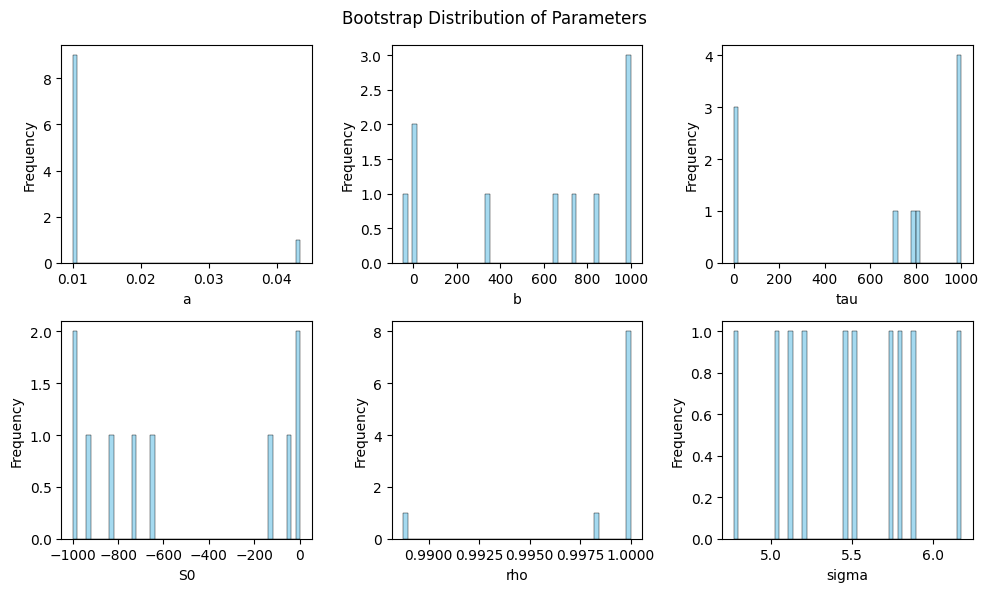

In [281]:
# plot histograms of bootstrap samples for each parameter; 
plt.figure(figsize=(10, 6))
for i, param in enumerate(bootstrap_params_df.columns):
    plt.subplot(2, 3, i+1)
    sns.histplot(bootstrap_params_df[param], bins=50, color='skyblue', edgecolor='black') #kde=True
    #plt.title(f'Bootstrap Distribution of {param}')
    plt.xlabel(param)
    plt.ylabel('Frequency')
    plt.suptitle('Bootstrap Distribution of Parameters')
plt.tight_layout()
plt.show()

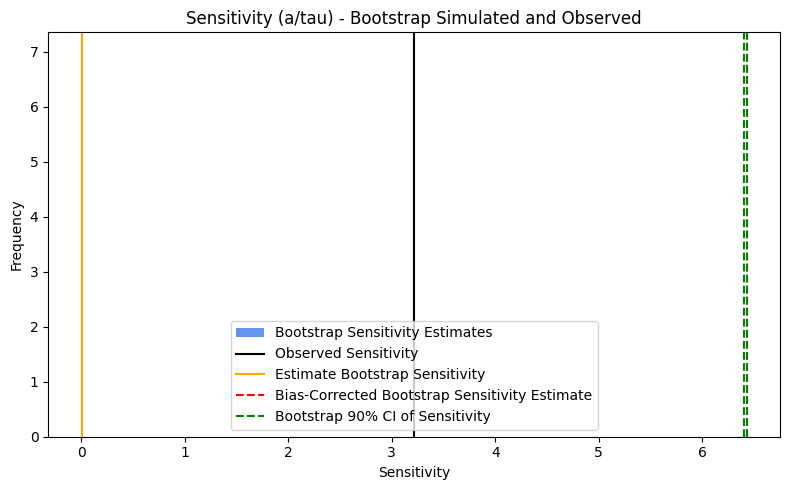

Sensitivity of sea level to global mean temperature (a/tau; all of the following have units mm/(year deg C)):
The bootstrap estimate of the sensitivity is 0.01;
The bias in this estimator (bootstrap estimate 0.01 minus original "observed" sensitivity 3.22) is -3.21.
The bias-adjusted estimate of the sensitivity is: 6.43.
The 90% confidence interval in the sensitivity estimate is 6.4 to 6.44.


In [282]:
# report 90% confidence interval for the sensitivity of sea level to global mean temperature (a/tau)
SL_original = a_hat/tau_hat
SL_sensitivity = bootstrap_params_df['a']/bootstrap_params_df['tau']
boot_estimate_SLS, boot_bias_SLS, estimate_true_param_SLS, boot_CI_low_SLS, boot_CI_high_SLS = basic_boot_CI(param_sample_est=SL_original, boot_sample=SL_sensitivity, quantile_low = 0.05, quantile_high = 0.95)

# Plot sensitivity
plt.figure(figsize=(8, 5))
plt.hist(SL_sensitivity, bins = 50, color = 'cornflowerblue', label = f'Bootstrap Sensitivity Estimates')
plt.axvline(x=SL_original, color = 'black',label='Observed Sensitivity')
plt.axvline(x=boot_estimate_SLS, color = 'orange',label='Estimate Bootstrap Sensitivity')
plt.axvline(x=estimate_true_param_SLS, color = 'red', linestyle='--',label='Bias-Corrected Bootstrap Sensitivity Estimate')
plt.axvline(x=boot_CI_low_SLS, color = 'green', linestyle='--', label='Bootstrap 90% CI of Sensitivity')
plt.axvline(x=boot_CI_high_SLS, color = 'green', linestyle='--')
plt.xlabel("Sensitivity")
plt.ylabel("Frequency")
plt.legend()
plt.title(fr"Sensitivity (a/tau) - Bootstrap Simulated and Observed")
plt.tight_layout()
plt.show()


print('Sensitivity of sea level to global mean temperature (a/tau; all of the following have units mm/(year deg C)):')
print(f'The bootstrap estimate of the sensitivity is {round(boot_estimate_SLS, 2)};')
print(f'The bias in this estimator (bootstrap estimate {round(boot_estimate_SLS, 2)} minus original "observed" sensitivity {round(SL_original,2)}) is {round(boot_bias_SLS, 2)}.')
print(f'The bias-adjusted estimate of the sensitivity is: {round(estimate_true_param_SLS, 2)}.')
print(f'The 90% confidence interval in the sensitivity estimate is {round(boot_CI_low_SLS, 2)} to {round(boot_CI_high_SLS,2)}.')

**COMMENTARY:**

Above, the sea level model was fit to the data using an AR(1) residual process. Then, 1,000 parametric bootstrap samples were generated from this fitted model and AR(1) process, the sea level model was refit to each sample. This histograms above show the distributions of the resulting estimates of the parameters. As noted above and discussed on EdDiscussions, the estimates of the parameter values can vary widely depending on the minimization method chosen, and can also vary widely from bootstrap sample to bootstrap sample (as illustrated in the histograms). However, the actual value of these parameters is relatively meaningless - the relationship **between** them is what we actually care about. This is explored above in the examination of the sensitivity of sea level to global mean temperature, which is calculated as a/tau. The original estimate of a/tau (from the initial model fitting), the bootstrap estimate, the bias of this estimator, and the bias-corrected estimate of this sensitivity are all reported above. Additionally, the basic bootstrap 90% confidence interval is reported in the final print statement above this block, and varies widely. I've been having trouble setting the random seed correctly, but the last time I ran the script the 90% confidence interval was from XXXXX to XXXX mm/(year deg C).

****COME BACK - FILL OUT 90% INT


### Problem 3

Let’s revisit the 2015 Sewell’s Point tide gauge data, which consists of
hourly observations and predicted sea-level based on NOAA’s harmonic
model.

**NOTE: Used ChatGPT (openai, 2025) to convert the Juila code blocks to Python.**

/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_33855/556959089.py:3: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(fname, parse_dates=[["Date", "Time (GMT)"]])


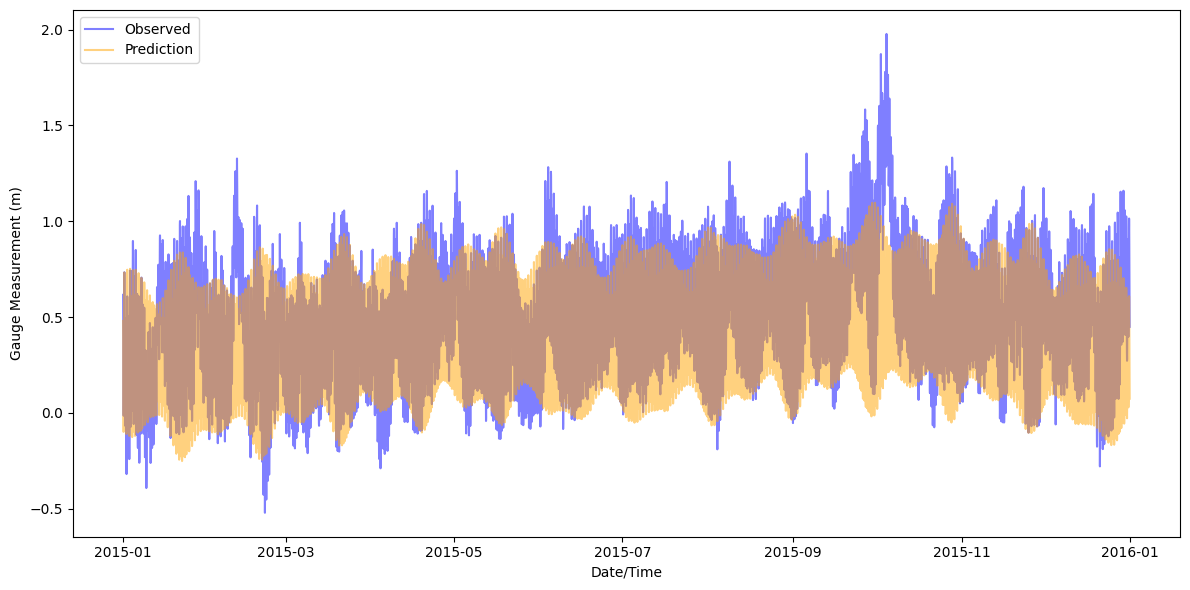

In [235]:
def load_data(fname):
    # Load CSV with parsed datetime
    df = pd.read_csv(fname, parse_dates=[["Date", "Time (GMT)"]])
    
    # Rename columns
    df.rename(columns={
        "Date_Time (GMT)": "datetime",
        "Predicted (m)": "harmonic",
        "Verified (m)": "gauge"
    }, inplace=True)

    # Compute additional columns
    df["weather"] = df["gauge"] - df["harmonic"]
    df["month"] = df["datetime"].dt.month

    return df[["datetime", "gauge", "harmonic", "weather", "month"]]

# Load the data
dat = load_data("data/norfolk-hourly-surge-2015.csv")

tide_median_observed = np.median(dat["gauge"])

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(dat["datetime"], dat["gauge"], label="Observed", color="blue", alpha = 0.5)
plt.plot(dat["datetime"], dat["harmonic"], label="Prediction", color="orange", alpha = 0.5)
plt.xlabel("Date/Time")
plt.ylabel("Gauge Measurement (m)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


We detrend the data to isolate the weather-induced variability by
subtracting the predictions from the observations; the results
(following the Julia code) are in `dat[:, :weather]`.

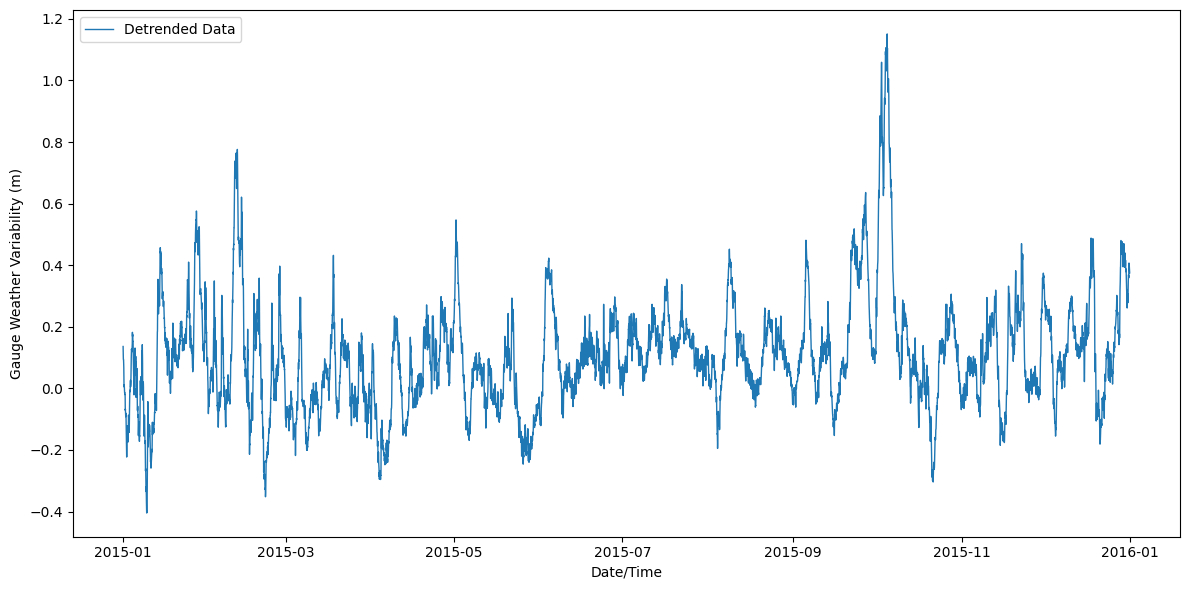

In [236]:
plt.figure(figsize=(12, 6))
plt.plot(dat["datetime"], dat["weather"], label="Detrended Data", linewidth=1)
plt.xlabel("Date/Time")
plt.ylabel("Gauge Weather Variability (m)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


We would like to understand the uncertainty in an estimate of the median
sea level.

**In this problem**:

-   Construct 1,000 bootstrap replicates by adding a moving block
    bootstrap replicate from the weather-induced variability series
    (with block length 20) to the harmonic prediction. Use these
    replicates to compute a 90% confidence interval. What is the bias of
    the estimator?
-   Repeat the analysis with block length 50. How does this affect the
    confidence intervals and estimate of bias?
-   Why do you think using different block lengths produced the results
    that they did?

**NOTE - use of ChatGPT (OpenAI, 2025) in this quesiton:** I used chatgpt to convert some of the code from the block bootstrap lecture slides from Julia to Python; all subsequent updates to that code were done by me, not ChatGPT.

The bootstrap (block length = 20) estimated median tide level is 0.513 meters;
The bias in this estimator (bootstrap estiamte 0.513 minus observed median 0.508 m) is 0.005 m.
The bias-adjusted estimate of the median is: 0.503 m.
the 90% confidence interval in median tide level is 0.489 m to 0.516 m.


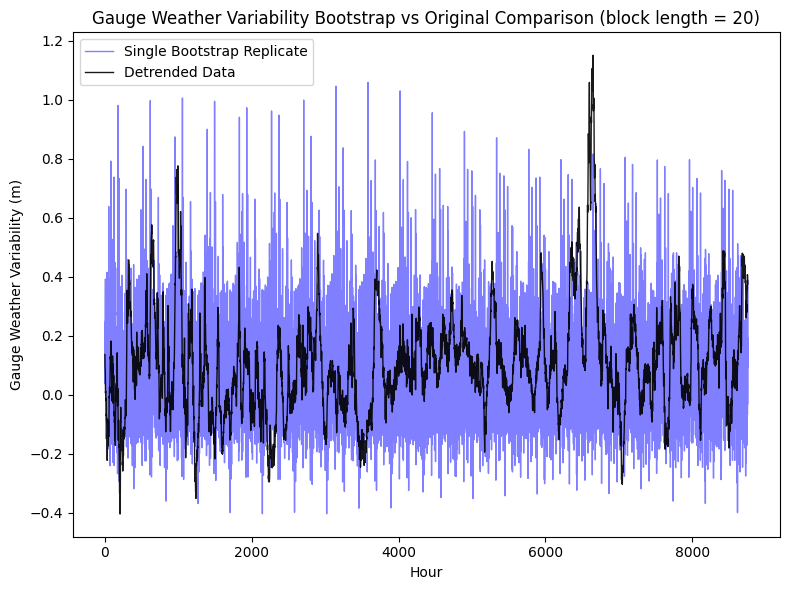

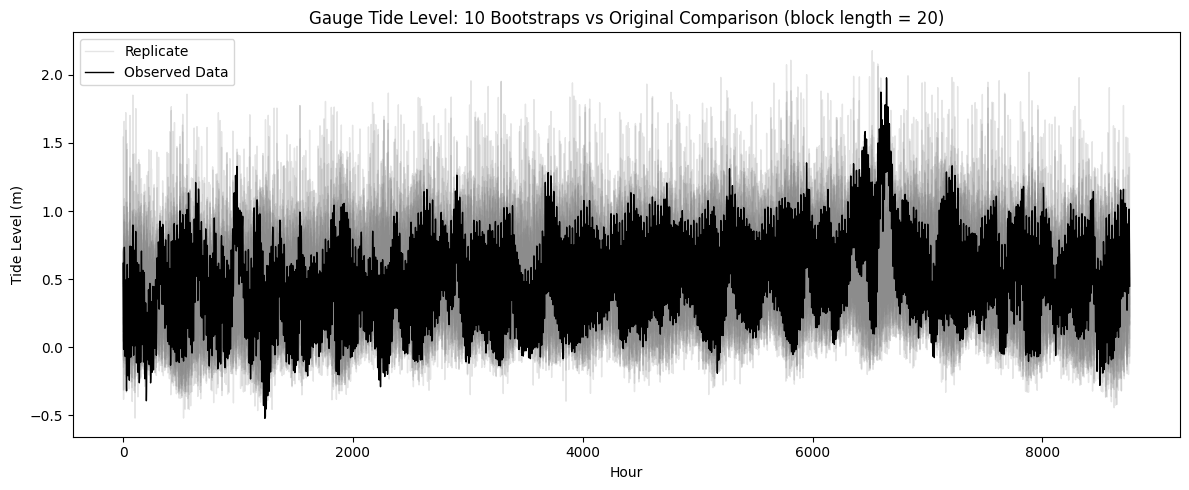

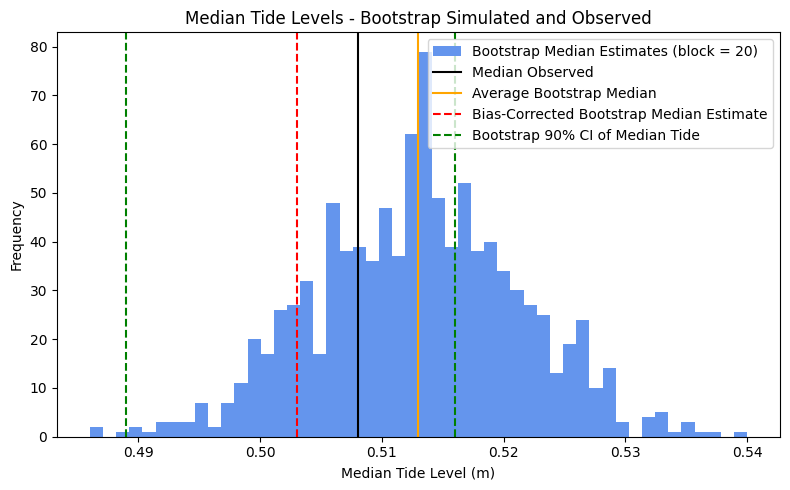

In [237]:
# create block bootstrap replicate of the weather-induced variability series (with block length 20) 
np.random.seed(4)
k = 20
n_blocks = len(dat["weather"]) - k + 1
blocks = np.zeros((k, n_blocks))
for i in range(n_blocks):
    blocks[:, i] = dat["weather"][i:(i + k)]

m = int(np.ceil(len(dat["weather"]) / k))
n_boot = 1000
weather_bootstrap20 = np.zeros((len(dat["weather"]), n_boot))
tide_bootstrap20 = np.zeros((len(dat["weather"]), n_boot))
median_tide_20 = []

# for each bootstrap sample - sample randomly from blocks, save weather variability bootstrap, and add it to
# harmonic to get actual tide bootstrap. Calculate and save median tide level from tide bootstrap for confidence intervals
for i in range(n_boot):
    block_sample_idx = np.random.choice(n_blocks, size=m, replace=True)
    resampled = np.concatenate(blocks[:, block_sample_idx], axis=0)
    weather_bootstrap20[:, i] = resampled[:len(dat["weather"])]  # Trim to original length if oversampled
    tide_bootstrap20[:, i] = dat['harmonic'] + weather_bootstrap20[:, i]
    # calculate and store median tide level:
    median_tide_20.append(np.median(tide_bootstrap20[:, i]))

# Use replicates to compute a 90% confidence interval in median tide level
# median20_expected = np.mean(median_tide_20)
# median20_05, median20_95 = np.quantile(median_tide_20, [0.05, 0.95])

# Using the basic bootstrap confidence interval function defined in problem 1:
#confidence intervals: 2 * param_sample_est - quantile_high <= actual param <= 2 * param_sample_est - quantile_low
boot_estimate_median20, boot_bias_median20, estimate_true_param_median20, boot_CI_low_median20, boot_CI_high_median20 = basic_boot_CI(param_sample_est=tide_median_observed, boot_sample=median_tide_20, quantile_low = 0.05, quantile_high = 0.95)

print(f'The bootstrap (block length = {k}) estimated median tide level is {round(boot_estimate_median20, 3)} meters;')
print(f'The bias in this estimator (bootstrap estiamte {round(boot_estimate_median20, 3)} minus observed median {round(tide_median_observed, 3)} m) is {round(boot_bias_median20, 3)} m.')
print(f'The bias-adjusted estimate of the median is: {round(estimate_true_param_median20, 3)} m.')
print(f'the 90% confidence interval in median tide level is {round(boot_CI_low_median20, 3)} m to {round(boot_CI_high_median20,3)} m.')

# Plot weather bootstrap
plt.figure(figsize=(8, 6))
plt.plot(weather_bootstrap20[:, 0], color="blue", linewidth=1, label="Single Bootstrap Replicate", alpha=0.5)
plt.plot(dat["weather"], color="black", linewidth=1, label="Detrended Data", alpha=0.9)
plt.xlabel("Hour")
plt.ylabel("Gauge Weather Variability (m)")
plt.title(f"Gauge Weather Variability Bootstrap vs Original Comparison (block length = {k})")
plt.legend()
plt.tight_layout()
plt.show()

# # Plot 10 bootstrap replicates
# plt.figure(figsize=(12, 5))
# plt.xlabel("Hour")
# plt.ylabel("Gauge Weather Variability (m)")
# plt.title("Gauge Weather Variability 10 Bootstraps vs Original Comparison (block length = 20)")
# for i in range(10):
#     label = "Replicate" if i == 0 else None  # Only label the first replicate
#     plt.plot(weather_bootstrap20[:, i], color="gray", alpha=0.2, linewidth=1, label=label)
# # Plot original data
# plt.plot(dat["weather"], color="black", linewidth=1, label="Data")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # Plot tide bootstrap
# plt.figure(figsize=(8, 6))
# plt.plot(tide_bootstrap20[:, 0], color="blue", linewidth=1, label="Single Tide Bootstrap", alpha=0.5)
# plt.plot(dat["gauge"], color="black", linewidth=1, label="Observed Data", alpha=0.9)
# plt.xlabel("Hour")
# plt.ylabel("Gauge level (m)")
# plt.title("Tide Gauge: Bootstrap vs Original Comparison (block length = 20)")
# plt.legend()
# plt.tight_layout()
# plt.show()

# Plot 10 bootstrap replicates
plt.figure(figsize=(12, 5))
plt.xlabel("Hour")
plt.ylabel("Tide Level (m)")
plt.title(f"Gauge Tide Level: 10 Bootstraps vs Original Comparison (block length = {k})")
for i in range(10):
    label = "Replicate" if i == 0 else None  # Only label the first replicate
    plt.plot(tide_bootstrap20[:, i], color="gray", alpha=0.2, linewidth=1, label=label)
# Plot original data
plt.plot(dat["gauge"], color="black", linewidth=1, label="Observed Data")
plt.legend()
plt.tight_layout()
plt.show()


# Plot the simulated time series median tide levels:
plt.figure(figsize=(8, 5))
plt.hist(median_tide_20, bins = 50, color = 'cornflowerblue', label = f'Bootstrap Median Estimates (block = {k})')
plt.axvline(x=tide_median_observed, color = 'black',label='Median Observed')
plt.axvline(x=boot_estimate_median20, color = 'orange',label='Average Bootstrap Median')
plt.axvline(x=estimate_true_param_median20, color = 'red', linestyle='--',label='Bias-Corrected Bootstrap Median Estimate')
plt.axvline(x=boot_CI_low_median20, color = 'green', linestyle='--', label='Bootstrap 90% CI of Median Tide')
plt.axvline(x=boot_CI_high_median20, color = 'green', linestyle='--')
plt.xlabel("Median Tide Level (m)")
plt.ylabel("Frequency")
plt.legend()
plt.title(fr"Median Tide Levels - Bootstrap Simulated and Observed")
plt.tight_layout()
plt.show()

The bootstrap (block length = 50) estimated median tide level is 0.512 meters;
The bias in this estimator (bootstrap estiamte 0.512 minus observed median 0.508 m) is 0.004 m.
The bias-adjusted estimate of the median is: 0.504 m.
the 90% confidence interval in median tide level is 0.484 m to 0.524 m.


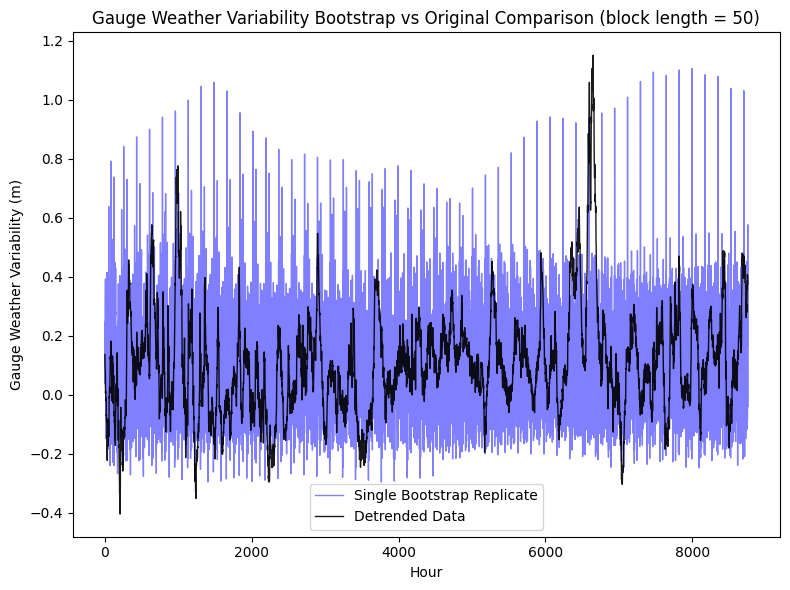

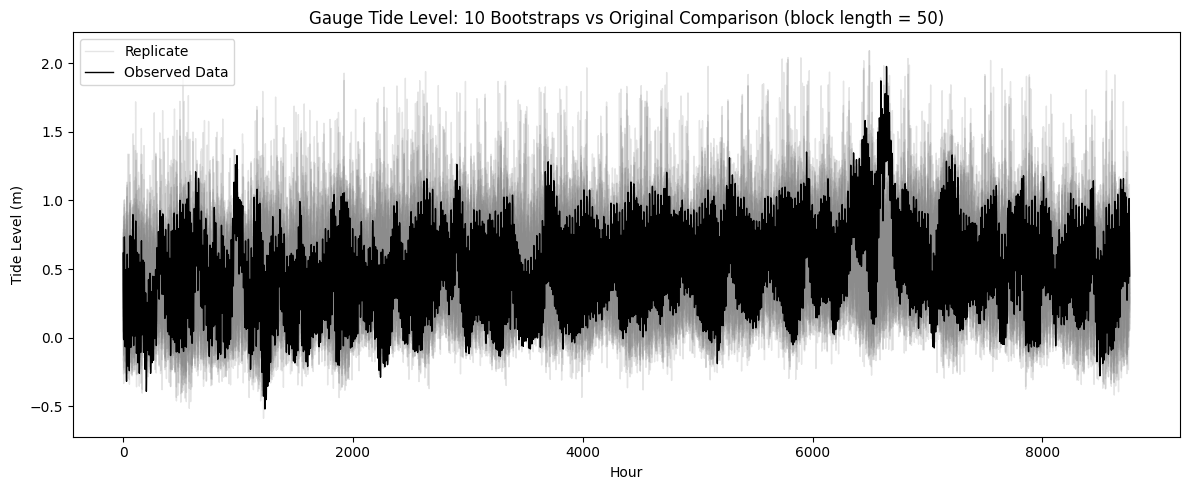

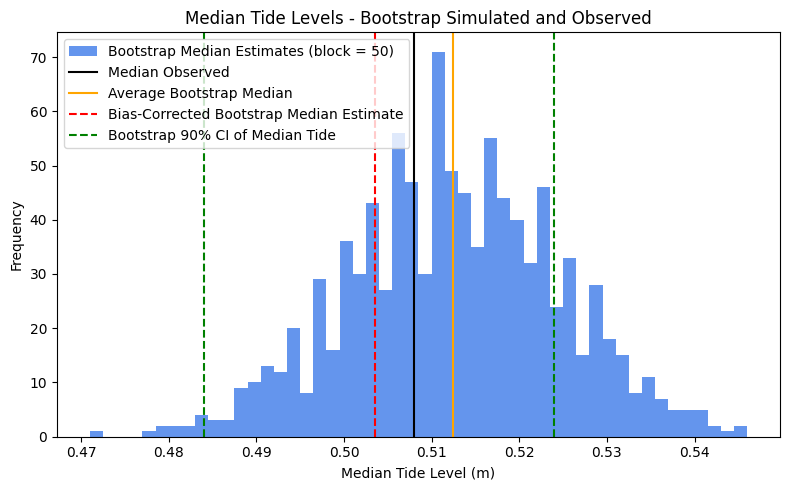

In [238]:
# create block bootstrap replicate of the weather-induced variability series (with block length 20) 
np.random.seed(4)
k = 50
n_blocks = len(dat["weather"]) - k + 1
blocks = np.zeros((k, n_blocks))
for i in range(n_blocks):
    blocks[:, i] = dat["weather"][i:(i + k)]

m = int(np.ceil(len(dat["weather"]) / k))
n_boot = 1000
weather_bootstrap20 = np.zeros((len(dat["weather"]), n_boot))
tide_bootstrap20 = np.zeros((len(dat["weather"]), n_boot))
median_tide_20 = []

# for each bootstrap sample - sample randomly from blocks, save weather variability bootstrap, and add it to
# harmonic to get actual tide bootstrap. Calculate and save median tide level from tide bootstrap for confidence intervals
for i in range(n_boot):
    block_sample_idx = np.random.choice(n_blocks, size=m, replace=True)
    resampled = np.concatenate(blocks[:, block_sample_idx], axis=0)
    weather_bootstrap20[:, i] = resampled[:len(dat["weather"])]  # Trim to original length if oversampled
    tide_bootstrap20[:, i] = dat['harmonic'] + weather_bootstrap20[:, i]
    # calculate and store median tide level:
    median_tide_20.append(np.median(tide_bootstrap20[:, i]))

# Use replicates to compute a 90% confidence interval in median tide level
# median20_expected = np.mean(median_tide_20)
# median20_05, median20_95 = np.quantile(median_tide_20, [0.05, 0.95])

# Using the basic bootstrap confidence interval function defined in problem 1:
#confidence intervals: 2 * param_sample_est - quantile_high <= actual param <= 2 * param_sample_est - quantile_low
boot_estimate_median20, boot_bias_median20, estimate_true_param_median20, boot_CI_low_median20, boot_CI_high_median20 = basic_boot_CI(param_sample_est=tide_median_observed, boot_sample=median_tide_20, quantile_low = 0.05, quantile_high = 0.95)

print(f'The bootstrap (block length = {k}) estimated median tide level is {round(boot_estimate_median20, 3)} meters;')
print(f'The bias in this estimator (bootstrap estiamte {round(boot_estimate_median20, 3)} minus observed median {round(tide_median_observed, 3)} m) is {round(boot_bias_median20, 3)} m.')
print(f'The bias-adjusted estimate of the median is: {round(estimate_true_param_median20, 3)} m.')
print(f'the 90% confidence interval in median tide level is {round(boot_CI_low_median20, 3)} m to {round(boot_CI_high_median20,3)} m.')

# Plot weather bootstrap
plt.figure(figsize=(8, 6))
plt.plot(weather_bootstrap20[:, 0], color="blue", linewidth=1, label="Single Bootstrap Replicate", alpha=0.5)
plt.plot(dat["weather"], color="black", linewidth=1, label="Detrended Data", alpha=0.9)
plt.xlabel("Hour")
plt.ylabel("Gauge Weather Variability (m)")
plt.title(f"Gauge Weather Variability Bootstrap vs Original Comparison (block length = {k})")
plt.legend()
plt.tight_layout()
plt.show()

# # Plot 10 bootstrap replicates
# plt.figure(figsize=(12, 5))
# plt.xlabel("Hour")
# plt.ylabel("Gauge Weather Variability (m)")
# plt.title("Gauge Weather Variability 10 Bootstraps vs Original Comparison (block length = 20)")
# for i in range(10):
#     label = "Replicate" if i == 0 else None  # Only label the first replicate
#     plt.plot(weather_bootstrap20[:, i], color="gray", alpha=0.2, linewidth=1, label=label)
# # Plot original data
# plt.plot(dat["weather"], color="black", linewidth=1, label="Data")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # Plot tide bootstrap
# plt.figure(figsize=(8, 6))
# plt.plot(tide_bootstrap20[:, 0], color="blue", linewidth=1, label="Single Tide Bootstrap", alpha=0.5)
# plt.plot(dat["gauge"], color="black", linewidth=1, label="Observed Data", alpha=0.9)
# plt.xlabel("Hour")
# plt.ylabel("Gauge level (m)")
# plt.title("Tide Gauge: Bootstrap vs Original Comparison (block length = 20)")
# plt.legend()
# plt.tight_layout()
# plt.show()

# Plot 10 bootstrap replicates
plt.figure(figsize=(12, 5))
plt.xlabel("Hour")
plt.ylabel("Tide Level (m)")
plt.title(f"Gauge Tide Level: 10 Bootstraps vs Original Comparison (block length = {k})")
for i in range(10):
    label = "Replicate" if i == 0 else None  # Only label the first replicate
    plt.plot(tide_bootstrap20[:, i], color="gray", alpha=0.2, linewidth=1, label=label)
# Plot original data
plt.plot(dat["gauge"], color="black", linewidth=1, label="Observed Data")
plt.legend()
plt.tight_layout()
plt.show()


# Plot the simulated time series median tide levels:
plt.figure(figsize=(8, 5))
plt.hist(median_tide_20, bins = 50, color = 'cornflowerblue', label = f'Bootstrap Median Estimates (block = {k})')
plt.axvline(x=tide_median_observed, color = 'black',label='Median Observed')
plt.axvline(x=boot_estimate_median20, color = 'orange',label='Average Bootstrap Median')
plt.axvline(x=estimate_true_param_median20, color = 'red', linestyle='--',label='Bias-Corrected Bootstrap Median Estimate')
plt.axvline(x=boot_CI_low_median20, color = 'green', linestyle='--', label='Bootstrap 90% CI of Median Tide')
plt.axvline(x=boot_CI_high_median20, color = 'green', linestyle='--')
plt.xlabel("Median Tide Level (m)")
plt.ylabel("Frequency")
plt.legend()
plt.title(fr"Median Tide Levels - Bootstrap Simulated and Observed")
plt.tight_layout()
plt.show()

#### Commentary on Problem 4:

In this problem, I constructed 1,000 bootstrap replicates of tide levels using a moving block bootstrap (with block length 20, and block length 50) of weather-induced tidal variability, which was then added to the harmonic prediction to get a bootstrap sample of tide levels. After obtaining these 1,000 bootstrap replicates, I computed the bootstrap estimate of the median tide level, and the 90% confidence interval associated with this estimate via the basic bootstrap confidence interval calculation. 

The results are as follows (also printed above):

**For block length 20:**
The bootstrap estimated median tide level is 0.513 meters;
The bias in this estimator (bootstrap estiamte 0.513 minus observed median 0.508 m) is 0.005 m.
The bias-adjusted estimate of the median is: 0.503 m.
the 90% confidence interval in median tide level is 0.489 m to 0.516 m

**For block length 50:**
The bootstrap estimated median tide level is 0.512 meters;
The bias in this estimator (bootstrap estiamte 0.512 minus observed median 0.508 m) is 0.004 m.
The bias-adjusted estimate of the median is: 0.504 m.
the 90% confidence interval in median tide level is 0.484 m to 0.524 m

**How does this affect the confidence intervals and estimate of bias? Why do you think using different block lengths produced the results that they did?**
Overall, the bootstrap estimated median tide level and associated bias is very similar between the two block length bootstraps (bootstrap estimated median 0.001m smaller for the length 50 bootstrap, resulting in 0.001 smaller positive bias for the block length 50 bootstrap). Both estimators have (small) positive biases. This is not paricularly surprising for a few reasons - the main, is that the median is a relatively stable statistic (e.g., compared to the mean), and is not expected to vary widely on average over bootstrap samples (unless you were considering extreme block lengths - e.g., block length equal to the full dataset length, in which case the estiate of the median would be the same every time, vs. block length of 1, in which case it would of course vary more relatively). One way to think about this stability that I found helpful, was considering what happens to the median vs. the mean when "extremes" are chosen more often in a given bootstrap sample - smaller block sizes essentially enable more frequent sampling of extremes, and e.g., sampling 2 large extremes and 2 small extremes in a given bootstrap sample would potentially change the mean quite a lot (e.g., if the large extremes had a larger relative difference from the original mean than the small extremes - which happens a lot in many of the environtmental settings we've discussed). Conversely, this configuration of a bootstrap sample would potentially have little to no impact on the median, because the median estimate isn't influenced by the magnitudes of those extremes - thus, if you have a roughly equal number of larger extremes being selected for a given bootstrap sample as you do lower extremes, the median does not change. Since both of our block sizes are relatively small (compared to the length of the dataset), the impact on this relatively stable statistic is minimal.

The confidence intervals on the other hand have a slightly more pronounced difference between the two block bootstrap samples - namely, the 90% CI is sligtly wider for the larger block length (50). This indicates that there is (slightly) more variability in our estimate of the median tide level based on the 50-length block bootstrap than in the 20-length block bootstrap - i.e., greater uncertainty in the estimate. I think that all of the differences in our statistic between the two different block sampling approach boil down to the fact that our timeseries that we're sampling from is highly auto-correlated, and any block boostrap sampling will disrupt this autocorrelation (and alter properties of the resulting timeseries, in part related to "jumps" that occur when two blocks are glued together). I think the reason the 90% confidence interval is slight larger for the larger block length can be tied to the example described above related to sampling given extremes more or less frequently - with slightly smaller block length (20), there's a slighty larger chance that you're samping high extremes and low extremes in more "equal" amounts (i.e., in ways that will cause relatively small/negligible impacts on the median). The larger the block length (up until a certain point) - the more likely you are to have e.g., slightly more large extremes than small extremes in a given sample (vs. almost equal large and small extremes in a given sample), and vice versa. This is specifically the case because of how auto-correlated our samples are (e.g., if you pick a block with high extremes - you get "more" high extremes in a block length of 50, than one with 20, so it's harder to get roughly equal number of high and low extremes selected for a 50 block length sample comapred to a 20 block length sample).

## References

OpenAI. (2025). ChatGPT (April 9 version) [Large language model]. https://chatgpt.com/
